<h1 style="font-size: 36px; color: black; font-weight: bold;">
Amazon Customers Sentiment Analysis
</h1>


<h2 style="font-size: 22px; color: black; font-weight: bold;">
Project Overview
</h2>

<p style="font-size: 16px; color: black;">
This project analyzes Amazon customer reviews to understand customer sentiment, ratings, feedback patterns, and areas for product improvement. The reviews are cleaned and preprocessed before applying sentiment analysis to classify customer opinions as Positive, Negative, or Neutral.
</p>

<h2 style="font-size: 22px; color: black; font-weight: bold;">
Dataset and Data Preparation
</h2>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

In [2]:
df = pd.read_csv("Amazon_Sentiment_Analysis.csv")

In [4]:
!pip install nltk

In [5]:
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23-07-2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25-10-2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23-12-2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21-11-2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13-07-2013,513,0,0,0,0,0.0,0.0


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4915
Number of columns: 12


In [7]:
df.isnull().sum()

Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64

In [9]:
df = df.dropna(subset=["reviewText"])

In [10]:
print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 4914


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [12]:
df["overall"].value_counts().sort_index()

overall
1     244
2      80
3     142
4     527
5    3921
Name: count, dtype: int64

In [13]:
df = df.drop(columns=["Unnamed: 0"])

In [14]:
df.columns

Index(['reviewerName', 'overall', 'reviewText', 'reviewTime', 'day_diff',
       'helpful_yes', 'helpful_no', 'total_vote', 'score_pos_neg_diff',
       'score_average_rating', 'wilson_lower_bound'],
      dtype='str')

In [15]:
df["reviewText"].head()


0                                           No issues.
1    Purchased this for my device, it worked as adv...
2    it works as expected. I should have sprung for...
3    This think has worked out great.Had a diff. br...
4    Bought it with Retail Packaging, arrived legit...
Name: reviewText, dtype: str

In [16]:
df["cleaned_review"] = df["reviewText"].str.lower()

In [17]:
df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

In [18]:
df["cleaned_review"] = df["cleaned_review"].str.replace(r"\s+", " ", regex=True).str.strip()

In [19]:
df[["reviewText", "cleaned_review"]].head()

,reviewText,cleaned_review
0,No issues.,no issues
1,"Purchased this for my device, it worked as adv...",purchased this for my device it worked as adve...
2,it works as expected. I should have sprung for...,it works as expected i should have sprung for ...
3,This think has worked out great.Had a diff. br...,this think has worked out greathad a diff bran...
4,"Bought it with Retail Packaging, arrived legit...",bought it with retail packaging arrived legit ...


In [21]:
import nltk

In [23]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [24]:
df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

In [25]:
df[["reviewText", "cleaned_review"]].head()

,reviewText,cleaned_review
0,No issues.,issues
1,"Purchased this for my device, it worked as adv...",purchased device worked advertised never much ...
2,it works as expected. I should have sprung for...,works expected sprung higher capacity think ma...
3,This think has worked out great.Had a diff. br...,think worked greathad diff bran gb card went s...
4,"Bought it with Retail Packaging, arrived legit...",bought retail packaging arrived legit orange e...


In [27]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [28]:
sia = SentimentIntensityAnalyzer()

In [4]:
sia = SentimentIntensityAnalyzer()

In [7]:
df = df.dropna(subset=["reviewText"])

In [8]:
df = df.drop(columns=["Unnamed: 0"])

In [9]:
df["cleaned_review"] = df["reviewText"].str.lower()

In [11]:
import re

In [12]:
df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

In [13]:
df["cleaned_review"] = df["cleaned_review"].str.replace(r"\s+", " ", regex=True).str.strip()

In [14]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

In [15]:
df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

In [1]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [2]:
sia = SentimentIntensityAnalyzer()

In [4]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

df = pd.read_csv("Amazon_Sentiment_Analysis.csv")

df = df.dropna(subset=["reviewText"])
df = df.drop(columns=["Unnamed: 0"])

df["cleaned_review"] = df["reviewText"].str.lower()

df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: re.sub(r'[^a-zA-Z\s]', '', x)
)

df["cleaned_review"] = (
    df["cleaned_review"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

stop_words = set(stopwords.words("english"))

df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: " ".join(word for word in x.split() if word not in stop_words)
)

sia = SentimentIntensityAnalyzer()

In [5]:
sia.polarity_scores(df["cleaned_review"].iloc[0])

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [6]:
df["compound_score"] = df["cleaned_review"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

In [7]:
df["compound_score"].head(10)

0    0.0000
1    0.0000
2    0.4019
3    0.6486
4    0.8591
5    0.0000
6    0.8971
7    0.8221
8    0.0000
9    0.9167
Name: compound_score, dtype: float64

In [8]:
def get_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["compound_score"].apply(get_sentiment)

In [9]:
df["sentiment"].value_counts()

sentiment
Positive    3904
Negative     635
Neutral      375
Name: count, dtype: int64

In [10]:
df["sentiment"].value_counts(normalize=True) * 100

sentiment
Positive    79.446479
Negative    12.922263
Neutral      7.631258
Name: proportion, dtype: float64

In [12]:
import matplotlib.pyplot as plt

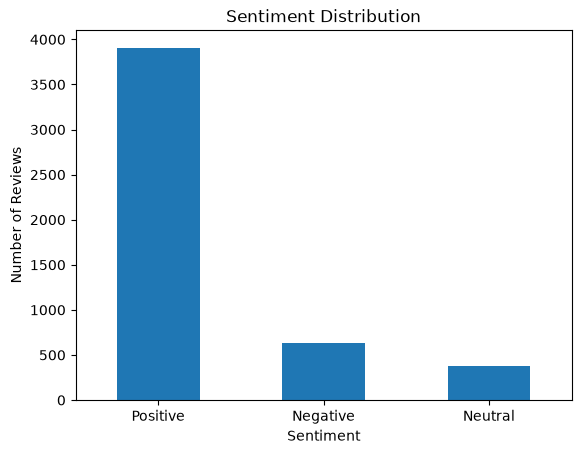

In [13]:
df["sentiment"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [14]:
pd.crosstab(df["overall"], df["sentiment"])

sentiment,Negative,Neutral,Positive
overall,,,
1,123,14,107
2,33,9,38
3,45,11,86
4,72,44,411
5,362,297,3262


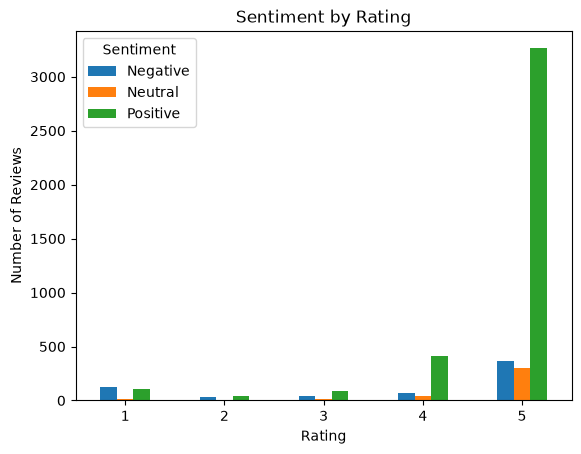

In [15]:
pd.crosstab(df["overall"], df["sentiment"]).plot(kind="bar")

plt.title("Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.show()

In [16]:
df["reviewTime"].head()

0    23-07-2014
1    25-10-2013
2    23-12-2012
3    21-11-2013
4    13-07-2013
Name: reviewTime, dtype: str

In [17]:
df["reviewTime"] = pd.to_datetime(df["reviewTime"], format="%d-%m-%Y")

In [18]:
df["year"] = df["reviewTime"].dt.year

In [19]:
df["year"].value_counts().sort_index()

year
2012     500
2013    2678
2014    1736
Name: count, dtype: int64

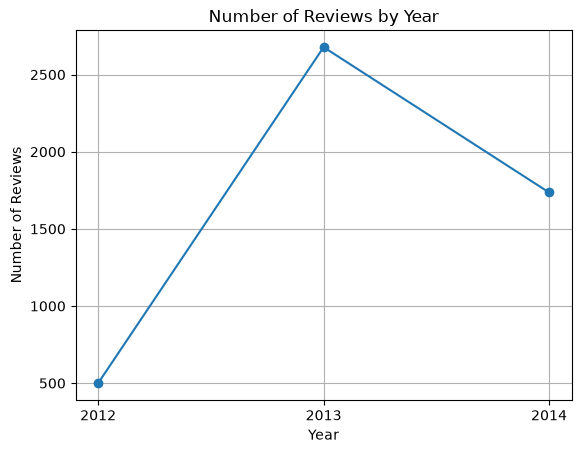

In [20]:
df["year"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks([2012, 2013, 2014])
plt.grid(True)
plt.show()

In [21]:
pd.crosstab(df["year"], df["sentiment"])

sentiment,Negative,Neutral,Positive
year,,,
2012,73,38,389
2013,360,187,2131
2014,202,150,1384


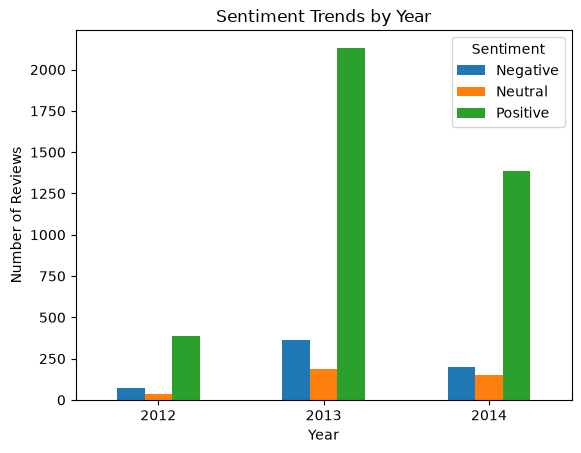

In [22]:
pd.crosstab(df["year"], df["sentiment"]).plot(kind="bar")

plt.title("Sentiment Trends by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.show()

In [23]:
df.groupby("sentiment")["overall"].mean()

sentiment
Negative    3.814173
Neutral     4.602667
Positive    4.711834
Name: overall, dtype: float64

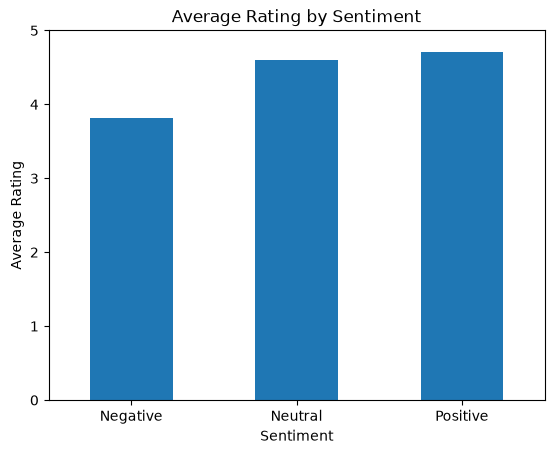

In [24]:
df.groupby("sentiment")["overall"].mean().plot(kind="bar")

plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.show()

In [25]:
from collections import Counter

all_words = " ".join(df["cleaned_review"]).split()
word_counts = Counter(all_words)

word_counts.most_common(15)

[('card', 4603),
 ('gb', 1725),
 ('phone', 1685),
 ('works', 1559),
 ('great', 1445),
 ('memory', 1361),
 ('sandisk', 1286),
 ('sd', 1199),
 ('use', 1115),
 ('one', 1072),
 ('galaxy', 1023),
 ('cards', 934),
 ('fast', 907),
 ('good', 891),
 ('price', 842)]

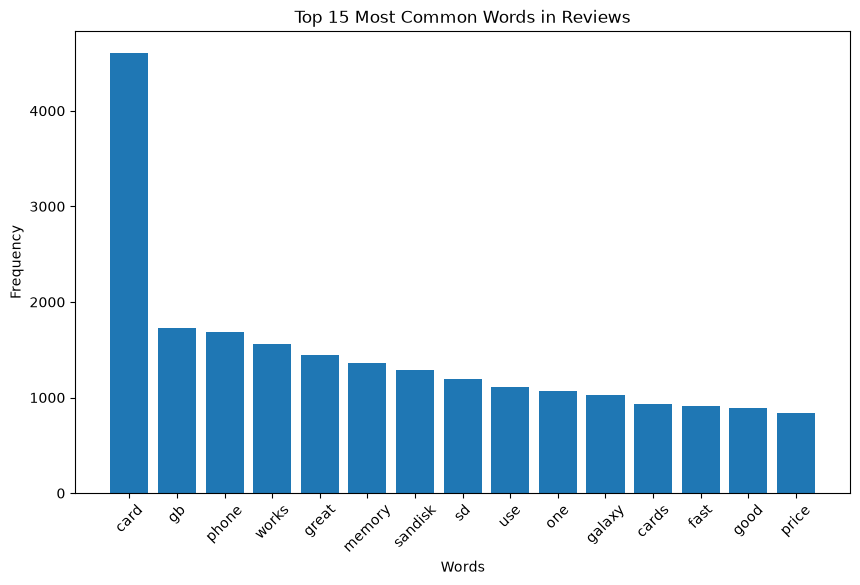

In [26]:
top_words = dict(word_counts.most_common(15))

plt.figure(figsize=(10, 6))
plt.bar(top_words.keys(), top_words.values())

plt.title("Top 15 Most Common Words in Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [27]:
df.groupby("sentiment")["helpful_yes"].mean()

sentiment
Negative    0.946457
Neutral     0.069333
Positive    1.489498
Name: helpful_yes, dtype: float64

In [28]:
df["overall"].value_counts().sort_index()

overall
1     244
2      80
3     142
4     527
5    3921
Name: count, dtype: int64

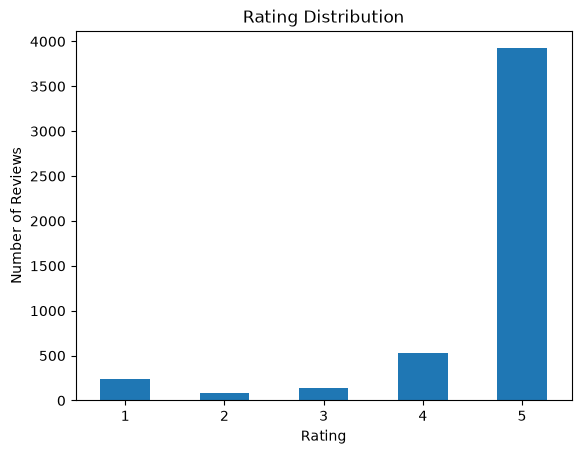

In [29]:
df["overall"].value_counts().sort_index().plot(kind="bar")

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

In [30]:
df["overall"].mean()

np.float64(4.587505087505088)

In [31]:
((df["overall"] >= 4).sum() / len(df)) * 100

np.float64(90.51689051689051)

In [32]:
(df["overall"] >= 4).sum()

np.int64(4448)

In [33]:
negative_words = " ".join(
    df[df["sentiment"] == "Negative"]["cleaned_review"]
).split()

negative_counts = Counter(negative_words)

negative_counts.most_common(15)

[('card', 779),
 ('phone', 295),
 ('gb', 237),
 ('sandisk', 222),
 ('one', 212),
 ('cards', 165),
 ('sd', 159),
 ('problem', 147),
 ('memory', 146),
 ('problems', 145),
 ('use', 138),
 ('galaxy', 128),
 ('bought', 122),
 ('would', 122),
 ('got', 113)]

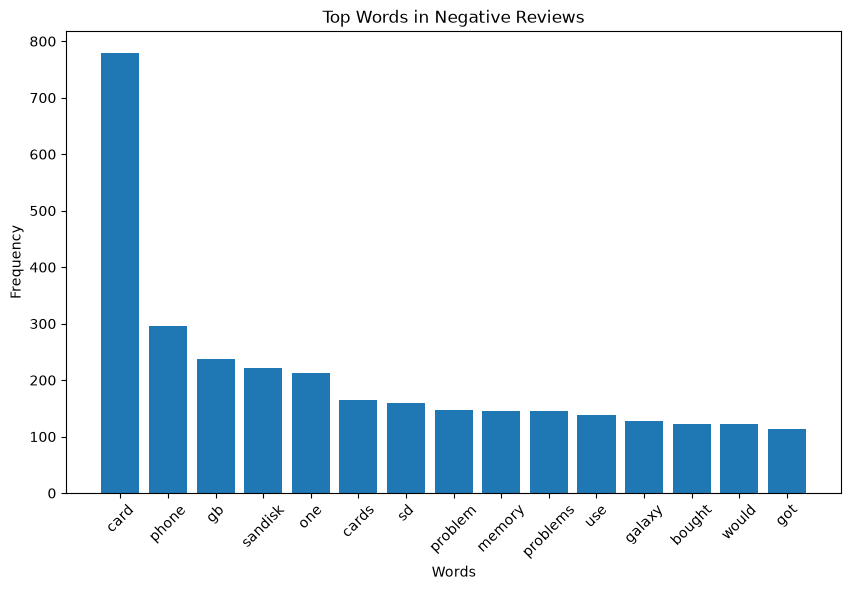

In [34]:
top_negative = dict(negative_counts.most_common(15))

plt.figure(figsize=(10, 6))
plt.bar(top_negative.keys(), top_negative.values())

plt.title("Top Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [35]:
(df["sentiment"] == "Negative").mean() * 100

np.float64(12.922262922262922)

<h2 style="font-size: 22px; color: black; font-weight: bold;">
Conclusion and Recommendations
</h2>

<p style="font-size: 16px; color: black;">
The analysis shows that Amazon customers have an overall positive experience, with an average rating of 4.59 out of 5 and 79.45% of reviews classified as positive. Most customers rated the product 4 or 5 stars. Negative reviews mainly highlighted product issues, phone compatibility, memory/storage concerns, and performance-related problems.
</p>

<p style="font-size: 16px; color: black;">
Based on these findings, improving product reliability, compatibility information, storage specifications, and customer support can help improve customer satisfaction and reduce negative feedback.
</p>

<h2 style="font-size: 22px; color: black; font-weight: bold;">
Final Visualizations
</h2>

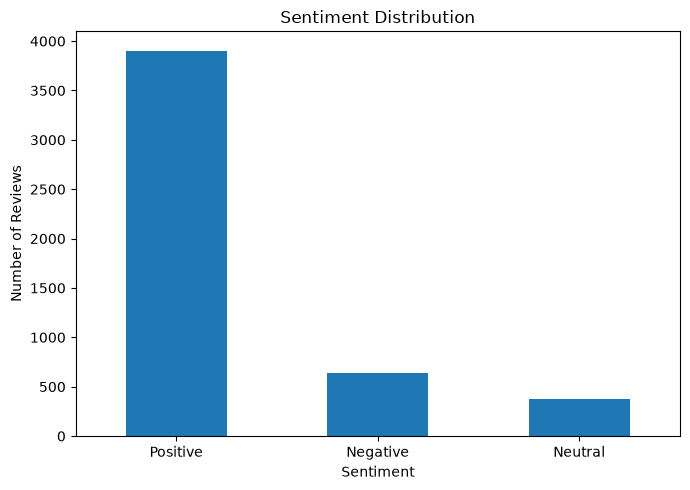

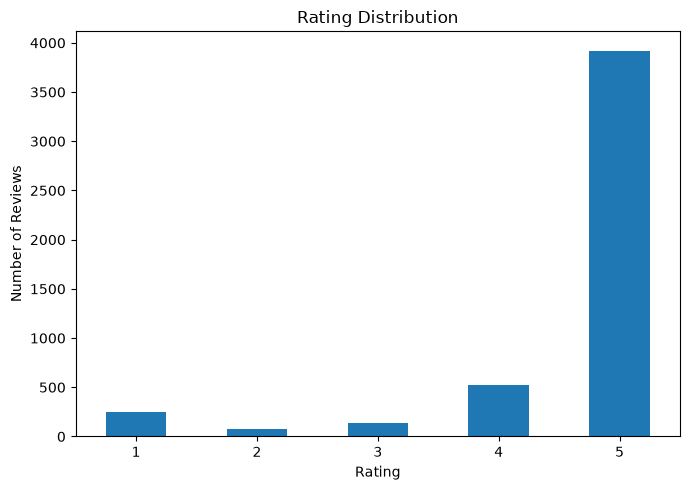

<Figure size 800x500 with 0 Axes>

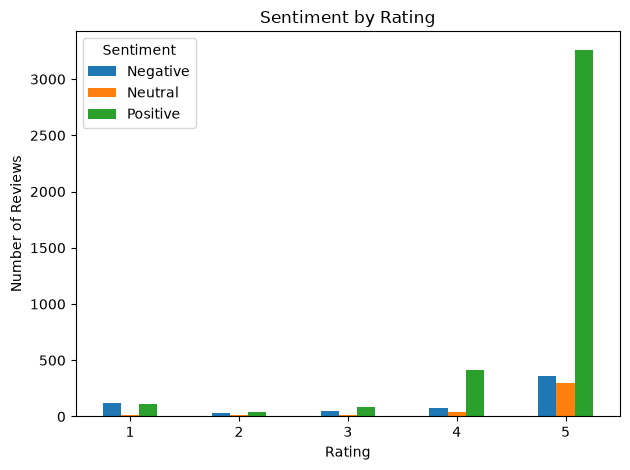

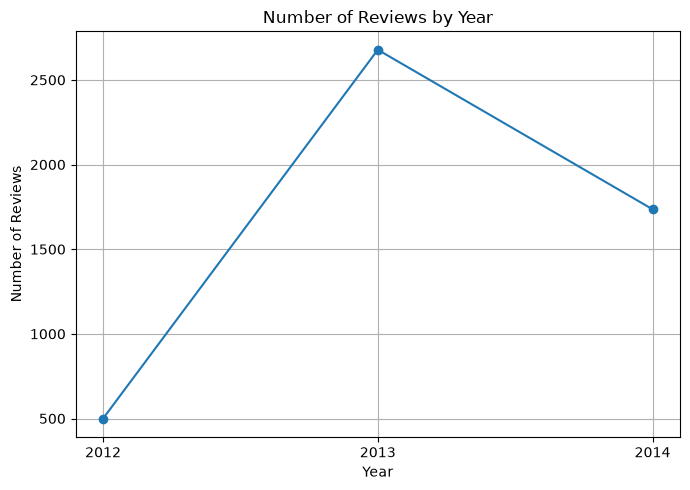

<Figure size 800x500 with 0 Axes>

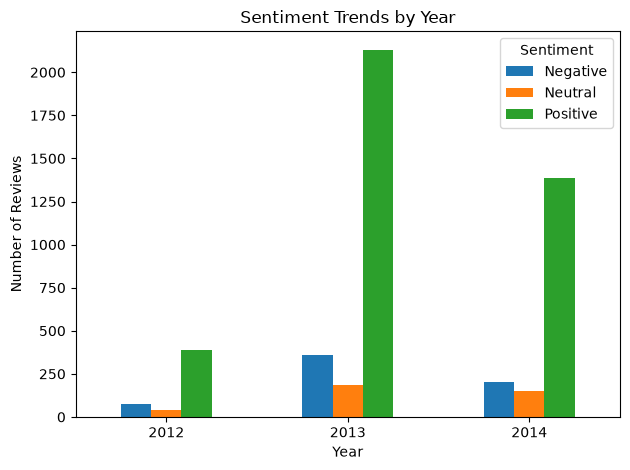

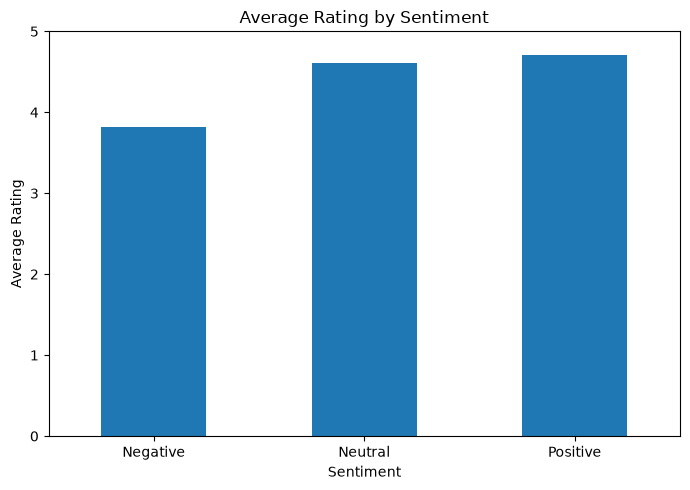

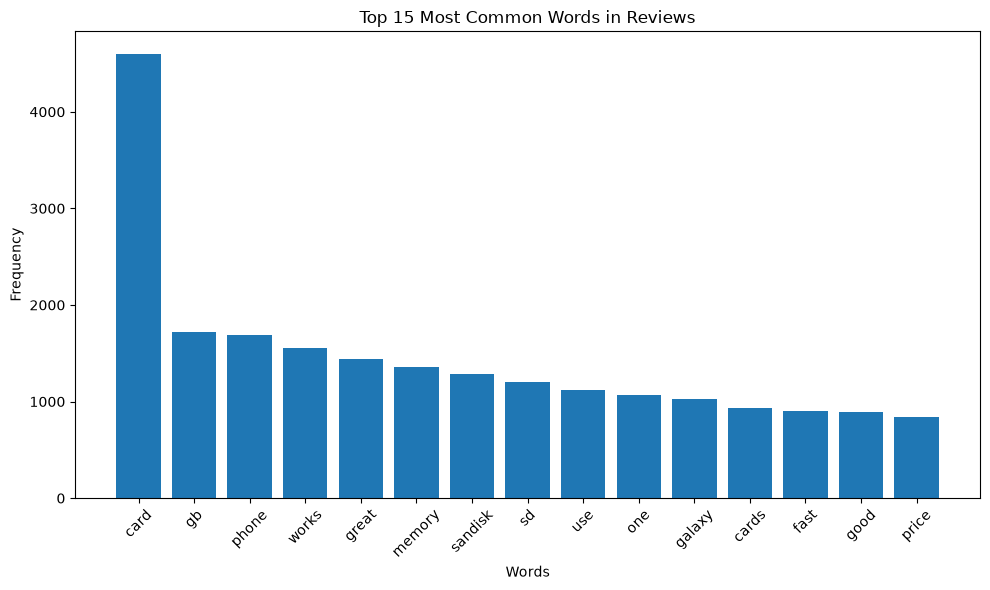

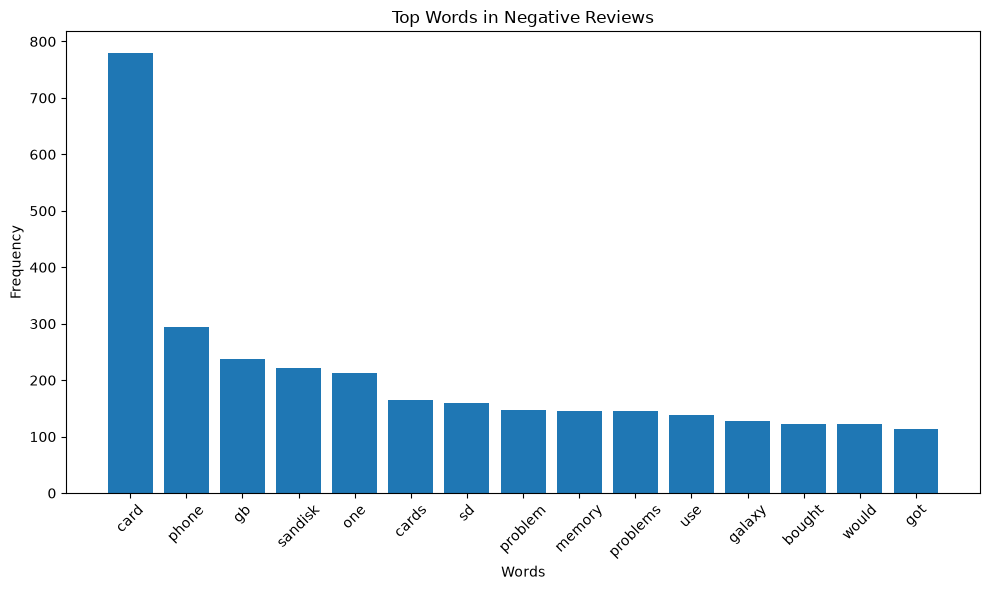

In [3]:
# ============================================================
# AMAZON CUSTOMER SENTIMENT ANALYSIS - FINAL VISUALIZATIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter



# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

df = pd.read_csv("Amazon_Sentiment_Analysis.csv")

# Remove missing review text
df = df.dropna(subset=["reviewText"])

# Remove unnecessary column
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# ------------------------------------------------------------
# 2. Text preprocessing
# ------------------------------------------------------------

stop_words = set(stopwords.words("english"))

df["cleaned_review"] = df["reviewText"].str.lower()

df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: re.sub(r"[^a-zA-Z\s]", "", x)
)

df["cleaned_review"] = df["cleaned_review"].str.replace(
    r"\s+", " ", regex=True
).str.strip()

df["cleaned_review"] = df["cleaned_review"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

# ------------------------------------------------------------
# 3. Sentiment analysis
# ------------------------------------------------------------

sia = SentimentIntensityAnalyzer()

df["compound_score"] = df["cleaned_review"].apply(
    lambda x: sia.polarity_scores(x)["compound"]
)

def get_sentiment(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["compound_score"].apply(get_sentiment)

# ------------------------------------------------------------
# 4. Convert review date and create year
# ------------------------------------------------------------

df["reviewTime"] = pd.to_datetime(
    df["reviewTime"],
    format="%d-%m-%Y"
)

df["year"] = df["reviewTime"].dt.year

# ------------------------------------------------------------
# 5. Word frequency
# ------------------------------------------------------------

all_words = " ".join(df["cleaned_review"]).split()
word_counts = Counter(all_words)

negative_words = " ".join(
    df[df["sentiment"] == "Negative"]["cleaned_review"]
).split()

negative_counts = Counter(negative_words)

# ============================================================
# FINAL VISUALIZATIONS
# ============================================================

# 1. Sentiment Distribution
plt.figure(figsize=(7, 5))
df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 2. Rating Distribution
plt.figure(figsize=(7, 5))
df["overall"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. Sentiment by Rating
plt.figure(figsize=(8, 5))
pd.crosstab(
    df["overall"],
    df["sentiment"]
).plot(kind="bar")

plt.title("Sentiment by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


# 4. Review Trend by Year
plt.figure(figsize=(7, 5))
df["year"].value_counts().sort_index().plot(
    kind="line",
    marker="o"
)
plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks([2012, 2013, 2014])
plt.grid(True)
plt.tight_layout()
plt.show()


# 5. Sentiment Trends by Year
plt.figure(figsize=(8, 5))
pd.crosstab(
    df["year"],
    df["sentiment"]
).plot(kind="bar")

plt.title("Sentiment Trends by Year")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


# 6. Average Rating by Sentiment
plt.figure(figsize=(7, 5))
df.groupby("sentiment")["overall"].mean().plot(
    kind="bar"
)
plt.title("Average Rating by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


# 7. Top 15 Common Words
top_words = dict(word_counts.most_common(15))

plt.figure(figsize=(10, 6))
plt.bar(top_words.keys(), top_words.values())
plt.title("Top 15 Most Common Words in Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 8. Top Words in Negative Reviews
top_negative = dict(negative_counts.most_common(15))

plt.figure(figsize=(10, 6))
plt.bar(top_negative.keys(), top_negative.values())
plt.title("Top Words in Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()